# Results Overview — Predicting the Failure of Crowded Technical Signals

## Core thesis
> Given a visible chart alert on a EURO STOXX 50 stock, predict whether that alert will **fail to follow through** over the next 1–5 sessions — and trade the reversal.

The model does **not** predict price direction. It predicts **signal reliability conditioned on context**: crowding, volatility regime, momentum, peer correlation, and market structure.

This notebook evaluates all 6 trained model variants and answers:
- Which alert types fail most reliably — and at which horizon?
- Which variant has the best discrimination and calibration?
- What features drive predictions?
- At what threshold does precision exceed the break-even for the live trade setup?

**Default (active) variant: `h1d_longonly`** — intraday holds, long-only, EOD close.

In [1]:
import sys, warnings, json
from pathlib import Path

ROOT      = Path('..').resolve()
AGENT     = ROOT / 'trading_agent'
MODEL_DIR = AGENT / 'data' / 'model'
CACHE_DIR = AGENT / 'data' / 'cache'
NB_CACHE  = ROOT / 'data' / 'features'
NB_CACHE.mkdir(parents=True, exist_ok=True)

for p in [str(ROOT), str(AGENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yaml
from sklearn.metrics import (roc_auc_score, roc_curve,
                              precision_recall_curve, precision_score, recall_score)
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (13, 5),
                     'axes.spines.top': False, 'axes.spines.right': False})

with open(AGENT / 'configs' / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

VARIANTS    = [('h1d_longonly', 1, 'longonly'), ('h3d_longonly', 3, 'longonly'),
               ('h5d_longonly', 5, 'longonly'), ('h1d_both',     1, 'both'),
               ('h3d_both',     3, 'both'),     ('h5d_both',     5, 'both')]
THRESHOLDS  = [0.50, 0.55, 0.60, 0.65, 0.70]
# Break-even: SL=1.5%, TP=2.5%, commission=0.10% rt → loss/(win+loss) = 1.6/4.0 = 40%
BREAKEVEN   = 0.40
ACTIVE      = cfg['model'].get('variant', 'h1d_longonly')

available = [v for v, _, _ in VARIANTS if (MODEL_DIR / f'xgboost_{v}.joblib').exists()]
print(f'Active variant    : {ACTIVE}')
print(f'Trained models    : {available or "NONE — run bootstrap_model.py --yfinance"}')
print(f'Break-even prec.  : {BREAKEVEN:.0%}  (SL=1.5%, TP=2.5%, commission=0.10% rt)')

Active variant    : h1d_longonly
Trained models    : ['h1d_longonly', 'h3d_longonly', 'h5d_longonly', 'h1d_both', 'h3d_both', 'h5d_both']
Break-even prec.  : 40%  (SL=1.5%, TP=2.5%, commission=0.10% rt)


In [ ]:
"""
Build the full feature + label pipeline.
Uses cached parquet files from data/features/ if available.
Set REBUILD=True to force a fresh build (required after changing features or retraining).
"""
REBUILD = False   # set True after retraining models or changing feature engineering
NB_LABELED = NB_CACHE / 'events_labeled_nb.parquet'
NB_FEATS   = NB_CACHE / 'feat_panel_nb.parquet'

if not REBUILD and NB_LABELED.exists() and NB_FEATS.exists():
    print('Loading notebook cache...')
    labeled    = pd.read_parquet(NB_LABELED)
    feat_panel = pd.read_parquet(NB_FEATS)
    print(f'  events: {len(labeled):,}  |  tickers: {labeled["ticker"].nunique()}  |  '
          f'date range: {labeled["date"].min().date()} - {labeled["date"].max().date()}')
else:
    print('Building pipeline (first run ~2-3 min for 50 tickers x 2yr)...')
    from src.data.preprocess import build_panel
    from src.features.engineering import build_features, add_alert_features
    from src.features.labels import compute_forward_returns, assign_labels
    from src.alerts.engine import run_alert_engine
    import yfinance as yf

    raw_dict = {}
    with open(ROOT / 'configs' / 'eurostoxx50_tickers.yaml') as f:
        tickers_list = yaml.safe_load(f)['tickers']

    for ticker in tickers_list:
        cache_file = CACHE_DIR / f"{ticker.replace('/', '_')}.parquet"
        if not cache_file.exists():
            print(f'  Fetching {ticker} from yfinance...')
            raw = yf.download(ticker, start='2010-01-01', auto_adjust=True, progress=False)
            if raw.empty: continue
            raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
            df = raw[['Open','High','Low','Close','Volume']].copy()
            df.columns = ['open','high','low','close','volume']
            df.index = pd.to_datetime(df.index)
            df = df[df['close'] > 0].reset_index().rename(columns={'index':'date','Date':'date'})
            df['ticker'] = ticker
            cache_file.parent.mkdir(parents=True, exist_ok=True)
            df.to_parquet(cache_file, index=False)
        df = pd.read_parquet(cache_file)
        d = df.rename(columns={'open':'Open','high':'High','low':'Low',
                               'close':'Close','volume':'Volume'}).copy()
        d.index = pd.to_datetime(d['date'] if 'date' in d.columns else d.index)
        d['ticker'] = ticker
        raw_dict[ticker] = d

    try:
        idx = yf.download('^STOXX50E', start='2010-01-01', auto_adjust=True, progress=False)
        idx.columns = [c[0] if isinstance(c, tuple) else c for c in idx.columns]
        index_close = idx['Close'].copy()
        index_close.index = pd.to_datetime(index_close.index)
    except Exception:
        index_close = None
        print('  Could not fetch index — regime features disabled')

    panel      = build_panel(raw_dict, min_history_days=cfg['model']['min_history_days'])
    print(f'  Panel: {panel.shape}')
    feat_panel = build_features(panel, index_close=index_close)
    feat_panel = compute_forward_returns(feat_panel, horizons=[1, 3, 5])
    events     = run_alert_engine(panel)
    events     = add_alert_features(events, panel)
    labeled    = assign_labels(events, feat_panel, horizons=[1, 3, 5], theta=0.005)

    feat_panel.to_parquet(NB_FEATS, index=False)
    labeled.to_parquet(NB_LABELED, index=False)
    print(f'  Cached to {NB_CACHE}')
    print(f'  events: {len(labeled):,}  |  tickers: {labeled["ticker"].nunique()}')

labeled['date'] = pd.to_datetime(labeled['date'])
labeled.head(3)

---
## 1. Alert Analysis

Which signals fire most often, and what fraction actually fail at each horizon?
A failure rate above 50% means the alert typically reverses — the baseline for a fade strategy.

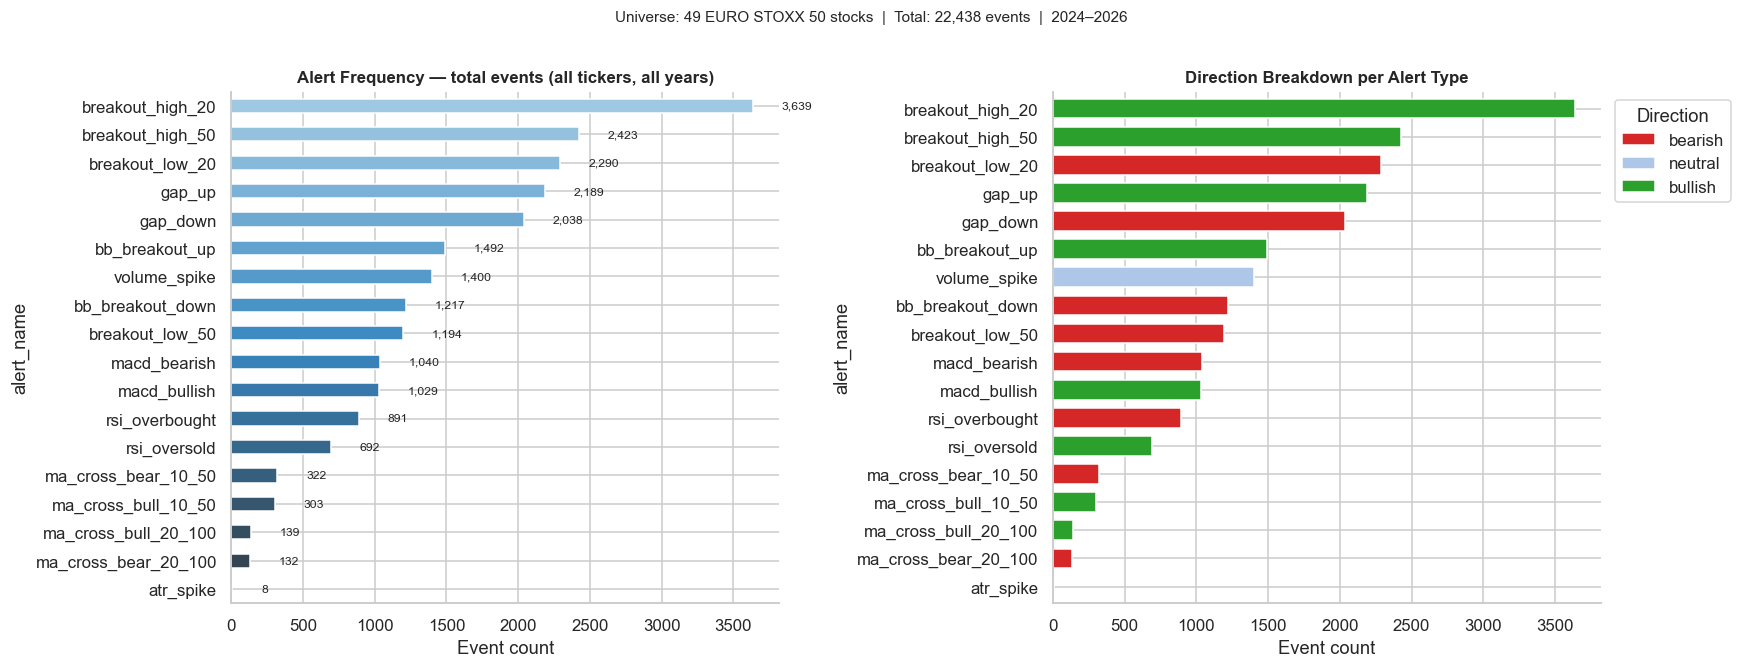

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Alert frequency ───────────────────────────────────────────────────────────
cnt = labeled['alert_name'].value_counts()
colors = sns.color_palette('Blues_d', len(cnt))
cnt.plot.barh(ax=axes[0], color=colors)
axes[0].set_title('Alert Frequency — total events (all tickers, all years)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Event count')
axes[0].invert_yaxis()
for i, v in enumerate(cnt.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=8)

# ── Direction breakdown ───────────────────────────────────────────────────────
dir_cnt = (labeled.groupby(['alert_name', 'direction'])
           .size().unstack(fill_value=0)
           [['bearish', 'neutral', 'bullish'] if 'neutral' in labeled['direction'].unique()
            else ['bearish', 'bullish']])
dir_cnt = dir_cnt.loc[cnt.index]   # same order
dir_cnt.plot.barh(ax=axes[1], stacked=True,
                  color=['#d62728', '#aec7e8', '#2ca02c'], width=0.7)
axes[1].set_title('Direction Breakdown per Alert Type', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Event count')
axes[1].invert_yaxis()
axes[1].legend(title='Direction', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(f'Universe: {labeled["ticker"].nunique()} EURO STOXX 50 stocks  |  '
             f'Total: {len(labeled):,} events  |  '
             f'{labeled["date"].min().year}–{labeled["date"].max().year}',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

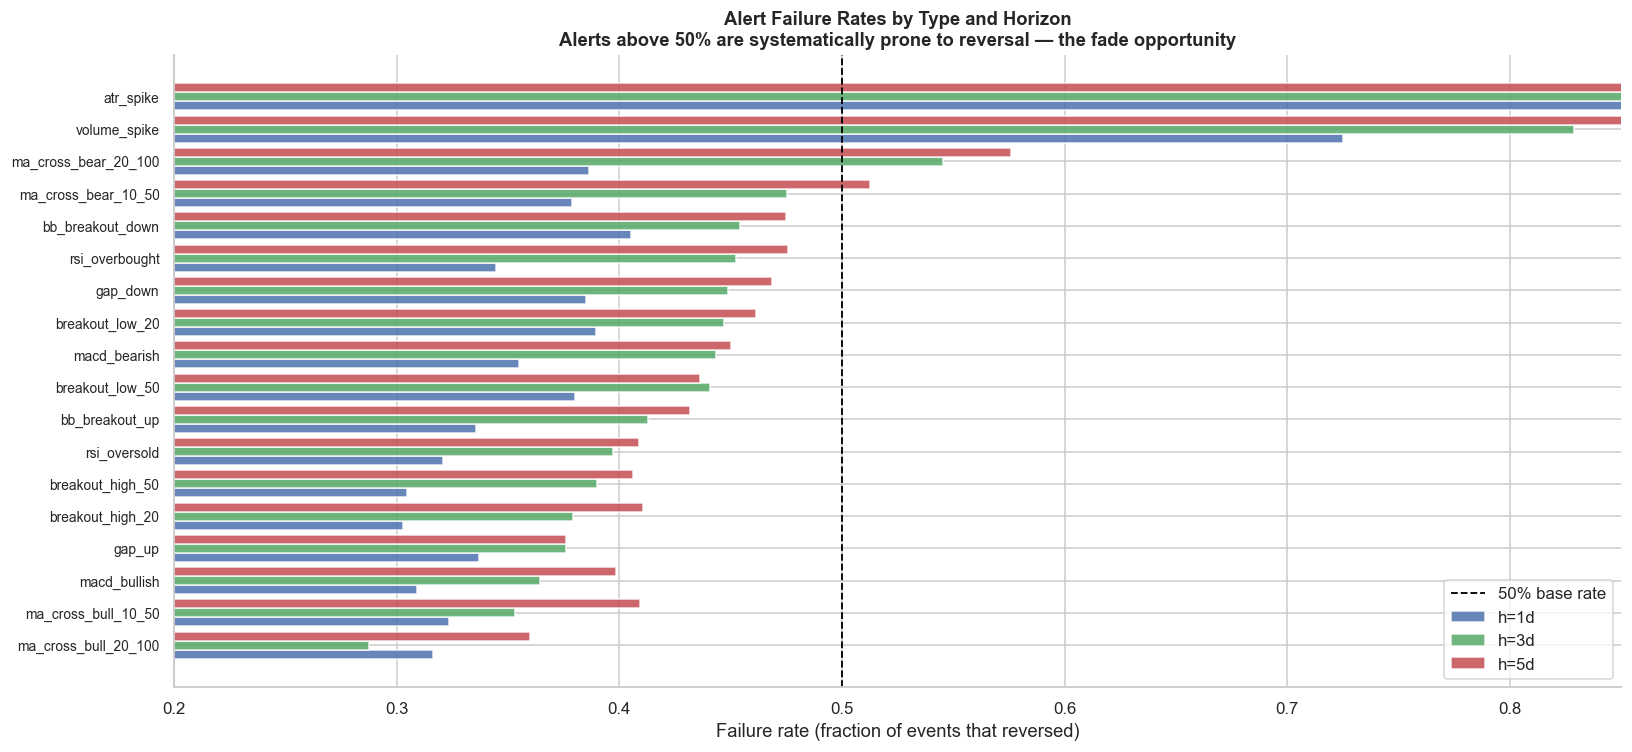


Alert failure rates (sorted by h=3d):
                      h=1d   h=3d   h=5d
alert_name                              
atr_spike            87.5% 100.0% 100.0%
volume_spike         72.5%  82.9%  89.3%
ma_cross_bear_20_100 38.6%  54.5%  57.6%
ma_cross_bear_10_50  37.9%  47.5%  51.2%
bb_breakout_down     40.5%  45.4%  47.5%
rsi_overbought       34.5%  45.2%  47.6%
gap_down             38.5%  44.9%  46.9%
breakout_low_20      39.0%  44.7%  46.2%
macd_bearish         35.5%  44.3%  45.0%
breakout_low_50      38.0%  44.1%  43.6%
bb_breakout_up       33.6%  41.3%  43.2%
rsi_oversold         32.1%  39.7%  40.9%
breakout_high_50     30.5%  39.0%  40.6%
breakout_high_20     30.3%  37.9%  41.1%
gap_up               33.7%  37.6%  37.6%
macd_bullish         30.9%  36.4%  39.8%
ma_cross_bull_10_50  32.3%  35.3%  40.9%
ma_cross_bull_20_100 31.7%  28.8%  36.0%


In [4]:
# ── Failure rates by alert type at each horizon ───────────────────────────────
# A failure means the expected continuation DID NOT happen → reversal → fade opportunity.
fail_by_alert = (
    labeled.groupby('alert_name')[['label_failure_1d','label_failure_3d','label_failure_5d']]
    .mean()
    .rename(columns={'label_failure_1d':'h=1d','label_failure_3d':'h=3d','label_failure_5d':'h=5d'})
    .sort_values('h=3d', ascending=True)
)

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(fail_by_alert))
w = 0.28
ax.barh(x - w,   fail_by_alert['h=1d'], w, label='h=1d', color='#4C72B0', alpha=0.85)
ax.barh(x,       fail_by_alert['h=3d'], w, label='h=3d', color='#55A868', alpha=0.85)
ax.barh(x + w,   fail_by_alert['h=5d'], w, label='h=5d', color='#C44E52', alpha=0.85)
ax.axvline(0.50, color='black', linestyle='--', linewidth=1.2, label='50% base rate')
ax.set_yticks(x)
ax.set_yticklabels(fail_by_alert.index, fontsize=9)
ax.set_xlabel('Failure rate (fraction of events that reversed)')
ax.set_title('Alert Failure Rates by Type and Horizon\n'
             'Alerts above 50% are systematically prone to reversal — the fade opportunity',
             fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.2, 0.85)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# Print table sorted by h=3d
print('\nAlert failure rates (sorted by h=3d):')
print(fail_by_alert.sort_values('h=3d', ascending=False)
      .to_string(float_format='{:.1%}'.format))

---
## 2. Model Evaluation — All 6 Variants

For each variant the model is evaluated on the **last 20% of the chronological sample** (strict hold-out, never seen during training).

Key metrics:
- **ROC-AUC**: discrimination — how well the model separates failures from non-failures (0.5 = random, 1.0 = perfect)
- **Precision @ threshold**: of all events flagged as failures at P ≥ threshold, what fraction actually reversed?
- **Break-even (40%)**: minimum precision for positive expected value given SL=1.5%, TP=2.5%, commission=0.10% round-trip

In [5]:
def _build_eval_matrix(labeled, feat_panel, horizon, mode):
    """Build (X, y, dates, feat_cols) for one variant from cached labeled events."""
    EXCLUDE = {'date','ticker','open','high','low','close','volume',
               'ret_1d_lead','fwd_ret_1d','fwd_ret_3d','fwd_ret_5d',
               'alert_name','direction','n_simultaneous_alerts','_dir_raw',
               'label_failure_1d','label_failure_3d','label_failure_5d'}

    feat_cols_all = [c for c in feat_panel.columns if c not in EXCLUDE]
    pf = feat_panel[['date','ticker'] + feat_cols_all].copy()
    pf['date'] = pd.to_datetime(pf['date'])

    lab = labeled.copy()
    lab['date'] = pd.to_datetime(lab['date'])
    # longonly: model trained on bearish/neutral events only (FADE -> BUY fades)
    if mode == 'longonly':
        lab = lab[lab['direction'].isin(['bearish','neutral'])].copy()

    lab['_dir_raw'] = lab['direction']
    lab = pd.get_dummies(lab, columns=['direction','alert_name'], drop_first=False)
    merged = lab.merge(pf.drop_duplicates(['date','ticker']),
                       on=['date','ticker'], how='left')

    # One-hot cols added by pd.get_dummies
    onehot_cols = [c for c in merged.columns
                   if c.startswith('direction_') or c.startswith('alert_name_')]
    # Feature cols from feat_panel (no forward-looking data)
    panel_feat_cols = [c for c in merged.columns if c in feat_cols_all]
    # Combine without duplicates; n_simultaneous_alerts comes from labeled (not feat_panel)
    feat_cols = list(dict.fromkeys(panel_feat_cols + onehot_cols + ['n_simultaneous_alerts']))
    feat_cols = [c for c in feat_cols if c in merged.columns
                 and merged[c].dtype != object]

    label_col = f'label_failure_{horizon}d'
    if label_col not in merged.columns:
        return None, None, None, None

    valid  = merged[label_col].notna()
    X      = merged.loc[valid, feat_cols].fillna(-1)
    y      = merged.loc[valid, label_col]
    dates  = pd.to_datetime(merged.loc[valid, 'date'])
    return X, y, dates, feat_cols


# ── Evaluate all available variants ──────────────────────────────────────────
eval_results = {}

for vname, horizon, mode in VARIANTS:
    mp = MODEL_DIR / f'xgboost_{vname}.joblib'
    cp = MODEL_DIR / f'feature_cols_{vname}.json'
    if not mp.exists():
        print(f'  [skip] {vname} — not trained')
        continue

    model          = joblib.load(mp)
    with open(cp) as f: feat_cols_trained = json.load(f)

    X, y, dates, _ = _build_eval_matrix(labeled, feat_panel, horizon, mode)
    if X is None:
        print(f'  [skip] {vname} — label column missing')
        continue

    common = [c for c in feat_cols_trained if c in X.columns]
    X      = X[common].fillna(-1)
    split  = int(len(X) * 0.80)
    X_v, y_v, d_v = X.iloc[split:], y.iloc[split:], dates.iloc[split:]

    if len(y_v) < 50:
        print(f'  [skip] {vname} — too few validation samples ({len(y_v)})')
        continue

    probas = model.predict_proba(X_v)[:, 1]
    auc    = roc_auc_score(y_v, probas)

    thr_stats = {}
    for t in THRESHOLDS:
        pred = (probas >= t).astype(int)
        n    = int(pred.sum())
        prec = float(precision_score(y_v, pred, zero_division=0)) if n > 5 else np.nan
        rec  = float(recall_score(y_v, pred, zero_division=0))    if n > 5 else np.nan
        thr_stats[t] = {'n': n, 'prec': prec, 'rec': rec}

    eval_results[vname] = {
        'horizon': horizon, 'mode': mode,
        'n_val': len(y_v), 'failure_rate': float(y_v.mean()),
        'auc': auc, 'probas': probas, 'y_val': y_v.values,
        'dates_val': d_v, 'thr': thr_stats,
        'importance': dict(zip(common, model.feature_importances_)),
    }
    active_mark = '  <- ACTIVE' if vname == ACTIVE else ''
    print(f'  {vname:<20s}  AUC={auc:.4f}  n={len(y_v):,}  '
          f'fail%={y_v.mean():.1%}{active_mark}')

print(f'\nEvaluated {len(eval_results)}/{len(VARIANTS)} variants.')

  h1d_longonly          AUC=0.7551  n=2,107  fail%=45.6%  <- ACTIVE
  h3d_longonly          AUC=0.7607  n=2,107  fail%=50.2%


  h5d_longonly          AUC=0.7631  n=2,107  fail%=54.2%
  h1d_both              AUC=0.6319  n=4,488  fail%=39.8%


  h3d_both              AUC=0.6836  n=4,488  fail%=45.3%
  h5d_both              AUC=0.6946  n=4,488  fail%=47.8%

Evaluated 6/6 variants.


Precision @ threshold  (* = above break-even 40%)

     Variant Hold     Mode    AUC N_val Fail%   P@0.5  P@0.55   P@0.6  P@0.65   P@0.7 Active
h1d_longonly   1d longonly 0.7551 2,107 45.6% 66.2% * 71.2% * 74.1% * 78.9% * 82.0% *    YES
h3d_longonly   3d longonly 0.7607 2,107 50.2% 68.0% * 73.3% * 76.2% * 80.4% * 84.4% *       
h5d_longonly   5d longonly 0.7631 2,107 54.2% 80.6% * 87.5% * 89.7% * 90.7% * 91.3% *       
    h1d_both   1d     both 0.6319 4,488 39.8% 54.2% * 71.7% * 80.1% * 81.7% * 92.8% *       
    h3d_both   3d     both 0.6836 4,488 45.3% 59.9% * 63.3% * 70.6% * 76.3% * 82.7% *       
    h5d_both   5d     both 0.6946 4,488 47.8% 63.1% * 70.5% * 79.7% * 86.8% * 90.5% *       


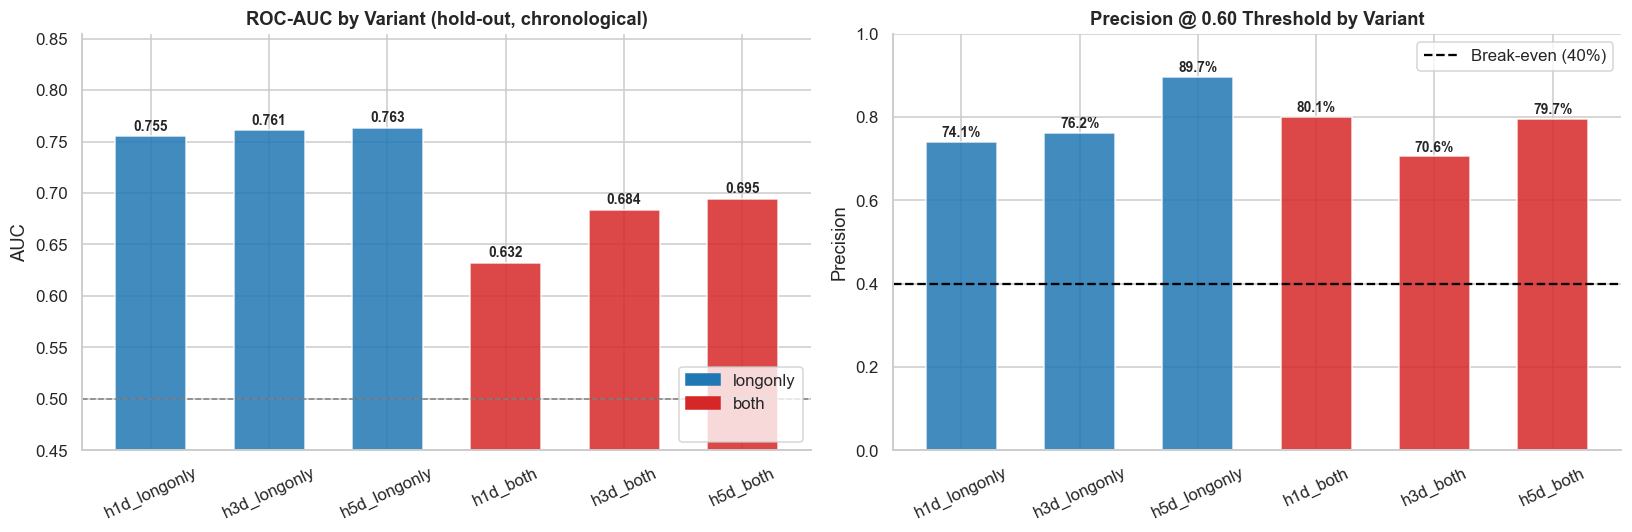

In [6]:
# ── Summary metrics table ─────────────────────────────────────────────────────
rows = []
for vname, r in eval_results.items():
    row = {'Variant': vname, 'Hold': f"{r['horizon']}d", 'Mode': r['mode'],
           'AUC': f"{r['auc']:.4f}", 'N_val': f"{r['n_val']:,}",
           'Fail%': f"{r['failure_rate']:.1%}"}
    for t in THRESHOLDS:
        s = r['thr'][t]
        prec = f"{s['prec']:.1%}" if not np.isnan(s['prec']) else '—'
        flag = ' *' if (not np.isnan(s['prec']) and s['prec'] >= BREAKEVEN) else ''
        row[f'P@{t}'] = prec + flag
        row[f'N@{t}'] = str(s['n'])
    row['Active'] = 'YES' if vname == ACTIVE else ''
    rows.append(row)

display_cols = ['Variant','Hold','Mode','AUC','N_val','Fail%'] + [f'P@{t}' for t in THRESHOLDS] + ['Active']
tbl = pd.DataFrame(rows)[display_cols]
print('Precision @ threshold  (* = above break-even 40%)\n')
print(tbl.to_string(index=False))

# ── AUC bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vnames = list(eval_results.keys())
aucs   = [eval_results[v]['auc'] for v in vnames]
cols   = ['#1f77b4' if 'longonly' in v else '#d62728' for v in vnames]
bars   = axes[0].bar(vnames, aucs, color=cols, alpha=0.85, width=0.6)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
axes[0].set_ylim(0.45, max(aucs) * 1.12)
axes[0].set_title('ROC-AUC by Variant (hold-out, chronological)', fontweight='bold')
axes[0].set_ylabel('AUC')
axes[0].tick_params(axis='x', rotation=25)
for b, v in zip(bars, aucs):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#1f77b4', label='longonly'), Patch(color='#d62728', label='both'),
    Patch(color='none', label='')], loc='lower right')

# Precision at 0.60 across variants
p60 = [eval_results[v]['thr'][0.60]['prec'] for v in vnames]
bars2 = axes[1].bar(vnames, p60, color=cols, alpha=0.85, width=0.6)
axes[1].axhline(BREAKEVEN, color='black', linestyle='--', linewidth=1.5,
                label=f'Break-even ({BREAKEVEN:.0%})')
axes[1].set_ylim(0, min(1.0, max(p for p in p60 if not np.isnan(p)) * 1.2 + 0.05))
axes[1].set_title('Precision @ 0.60 Threshold by Variant', fontweight='bold')
axes[1].set_ylabel('Precision')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()
for b, v in zip(bars2, p60):
    if not np.isnan(v):
        axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                     f'{v:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

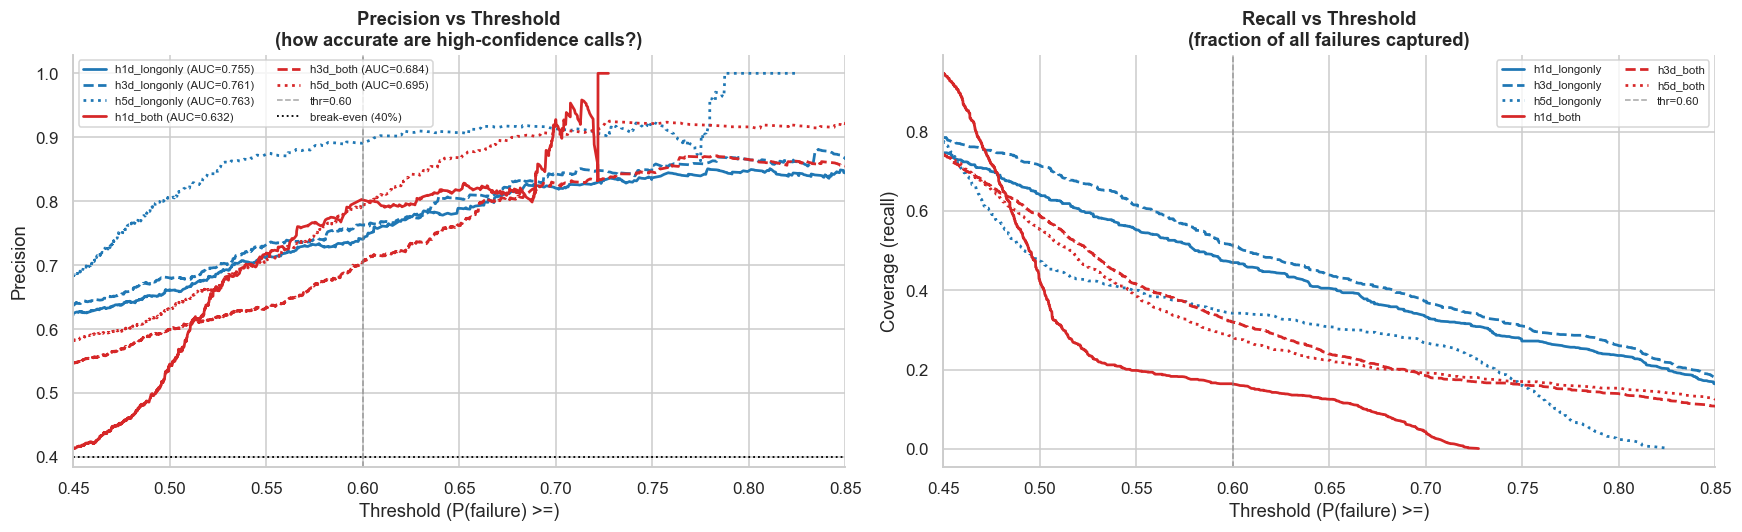

In [7]:
# ── Precision-threshold curves: how precision and coverage trade off ──────────
# Each curve shows: as we raise the threshold, precision increases but coverage (recall) drops.
# Note: precision_recall_curve returns len(prec) = len(thresh) + 1 (last point = precision at
# minimum threshold). We drop the extra element before masking.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

groups = {'longonly': '#1f77b4', 'both': '#d62728'}
styles = {1: 'solid', 3: 'dashed', 5: 'dotted'}

for vname, r in eval_results.items():
    prec_curve, rec_curve, thresh_curve = precision_recall_curve(r['y_val'], r['probas'])
    # sklearn: prec/rec have one extra element — drop it to align with thresh
    prec_curve = prec_curve[:-1]
    rec_curve  = rec_curve[:-1]

    mask = thresh_curve >= 0.45
    tc, pc, rc = thresh_curve[mask], prec_curve[mask], rec_curve[mask]
    lc = groups[r['mode']]
    ls = styles[r['horizon']]

    axes[0].plot(tc, pc, color=lc, linestyle=ls, linewidth=1.8,
                 label=f"{vname} (AUC={r['auc']:.3f})")
    axes[1].plot(tc, rc, color=lc, linestyle=ls, linewidth=1.8, label=vname)

for ax, ylabel, title in [
    (axes[0], 'Precision', 'Precision vs Threshold\n(how accurate are high-confidence calls?)'),
    (axes[1], 'Coverage (recall)', 'Recall vs Threshold\n(fraction of all failures captured)')]:
    ax.axvline(0.60, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='thr=0.60')
    if ax is axes[0]:
        ax.axhline(BREAKEVEN, color='black', linestyle=':', linewidth=1.2,
                   label=f'break-even ({BREAKEVEN:.0%})')
    ax.set_xlabel('Threshold (P(failure) >=)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0.45, 0.85)
    ax.legend(fontsize=7.5, ncol=2, loc='upper left' if ax is axes[0] else 'upper right')

plt.tight_layout()
plt.show()

---
## 3. Feature Importance

Which features drive predictions most for the active variant (`h1d_longonly`)?

Feature importance is read directly from the trained XGBoost model.  
- **Top chart**: top-20 features for the active variant — shows the dominant signals for intraday fade trades.  
- **Heatmap**: top-15 features across all 6 variants — reveals which features are universally important vs horizon/mode-specific.

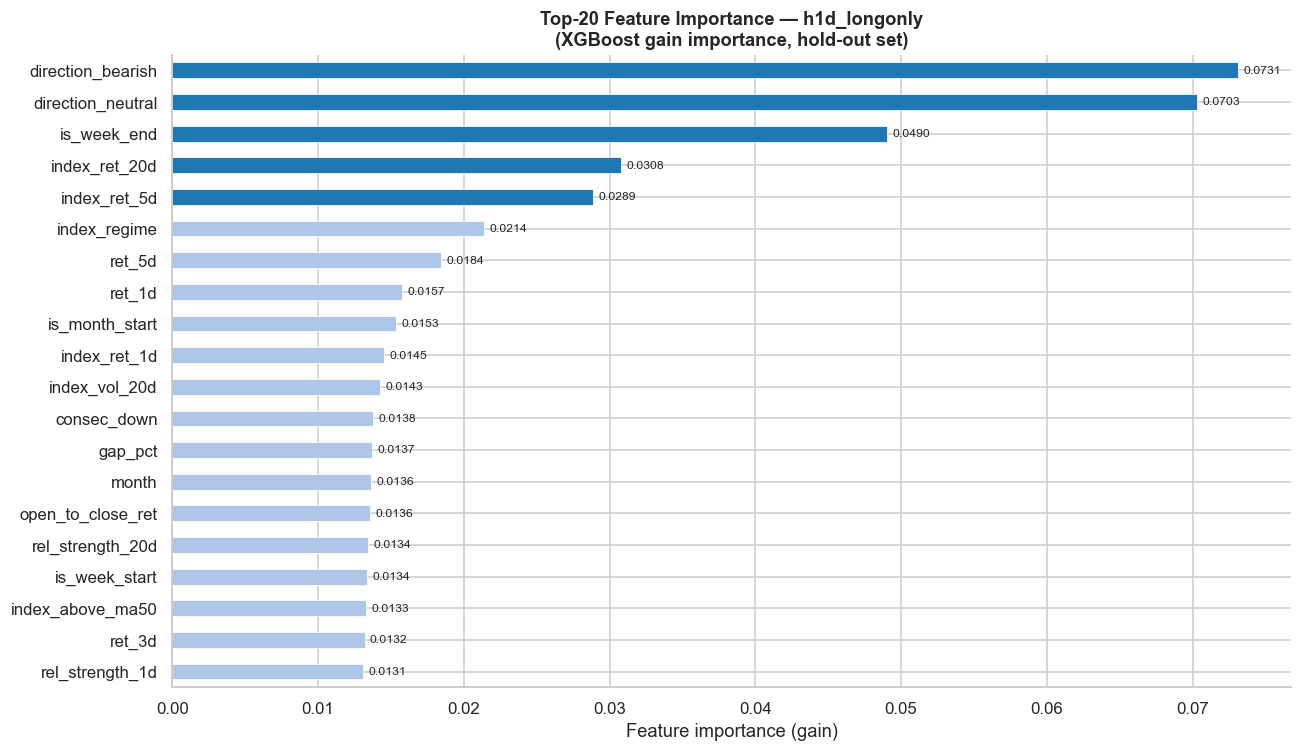


Top-10 features for h1d_longonly:
  direction_bearish                    0.0731
  direction_neutral                    0.0703
  is_week_end                          0.0490
  index_ret_20d                        0.0308
  index_ret_5d                         0.0289
  index_regime                         0.0214
  ret_5d                               0.0184
  ret_1d                               0.0157
  is_month_start                       0.0153
  index_ret_1d                         0.0145


In [8]:
# ── Feature importance: active variant top-20 ─────────────────────────────────
if ACTIVE in eval_results:
    imp_active = pd.Series(eval_results[ACTIVE]['importance']).sort_values(ascending=False)
    top20 = imp_active.head(20)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(top20))]
    top20[::-1].plot.barh(ax=ax, color=colors[::-1], edgecolor='white', linewidth=0.5)
    ax.set_title(f'Top-20 Feature Importance — {ACTIVE}\n'
                 f'(XGBoost gain importance, hold-out set)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Feature importance (gain)')
    for i, (feat, val) in enumerate(top20[::-1].items()):
        ax.text(val + imp_active.max() * 0.005, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f'\nTop-10 features for {ACTIVE}:')
    for feat, val in imp_active.head(10).items():
        print(f'  {feat:<35s}  {val:.4f}')
else:
    print(f'Active variant {ACTIVE} not in eval_results. Run cell-7 first.')

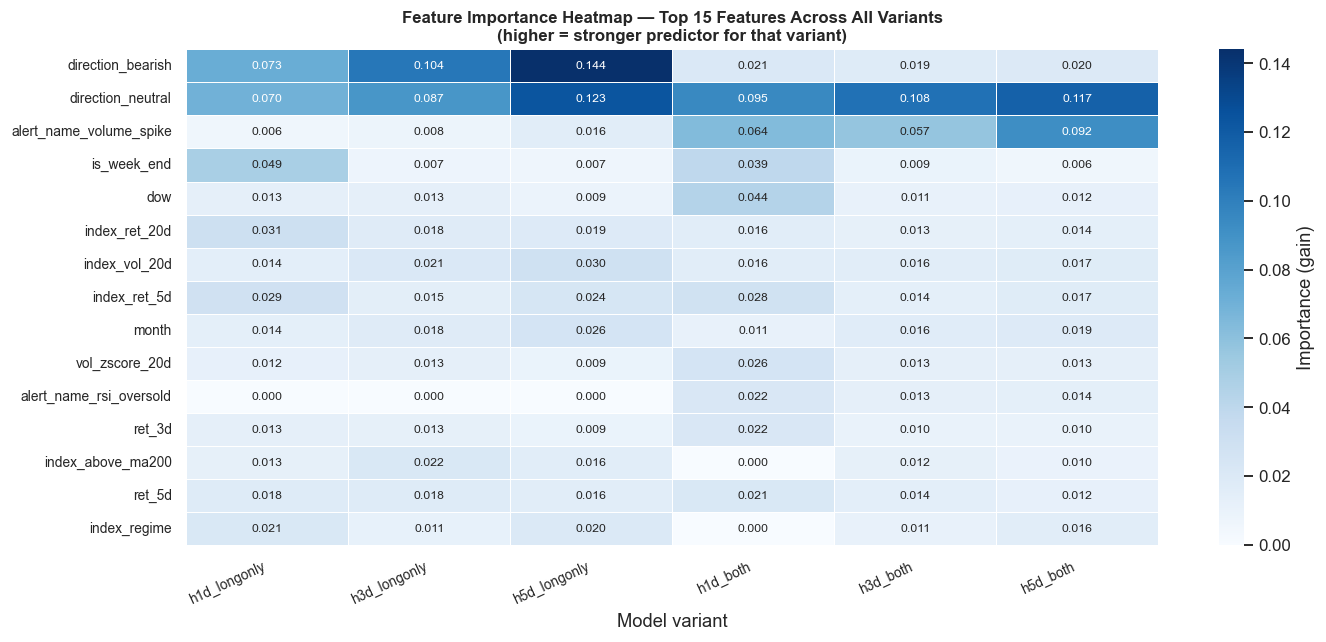


Interpretation guide:
  Dark cells = highly important for that variant
  Row spans all variants = universally important feature
  Column concentration = variant-specific driver


In [9]:
# ── Cross-variant feature importance heatmap ──────────────────────────────────
# Rank the top-15 features globally (by max importance across variants),
# then show each variant's importance as a heatmap.

if eval_results:
    all_imp = pd.DataFrame({
        vname: pd.Series(r['importance'])
        for vname, r in eval_results.items()
    }).fillna(0)

    # Select top-15 by max importance across all variants
    top_feats = all_imp.max(axis=1).sort_values(ascending=False).head(15).index
    hm_data = all_imp.loc[top_feats]

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(hm_data, ax=ax, cmap='Blues', linewidths=0.4, linecolor='white',
                fmt='.3f', annot=True, annot_kws={'size': 8},
                cbar_kws={'label': 'Importance (gain)'})
    ax.set_title('Feature Importance Heatmap — Top 15 Features Across All Variants\n'
                 '(higher = stronger predictor for that variant)',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Model variant')
    ax.set_ylabel('')
    plt.xticks(rotation=25, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('\nInterpretation guide:')
    print('  Dark cells = highly important for that variant')
    print('  Row spans all variants = universally important feature')
    print('  Column concentration = variant-specific driver')

---
## 4. Calibration

A well-calibrated model means: when it says P(failure) = 0.65, ~65% of those events actually reversed.  
Poor calibration → thresholds that don't translate to real precision.

The chart below bins predicted probabilities into 10 decile buckets and compares them to the actual failure rate in each bucket.  
A perfectly calibrated model would lie on the diagonal.

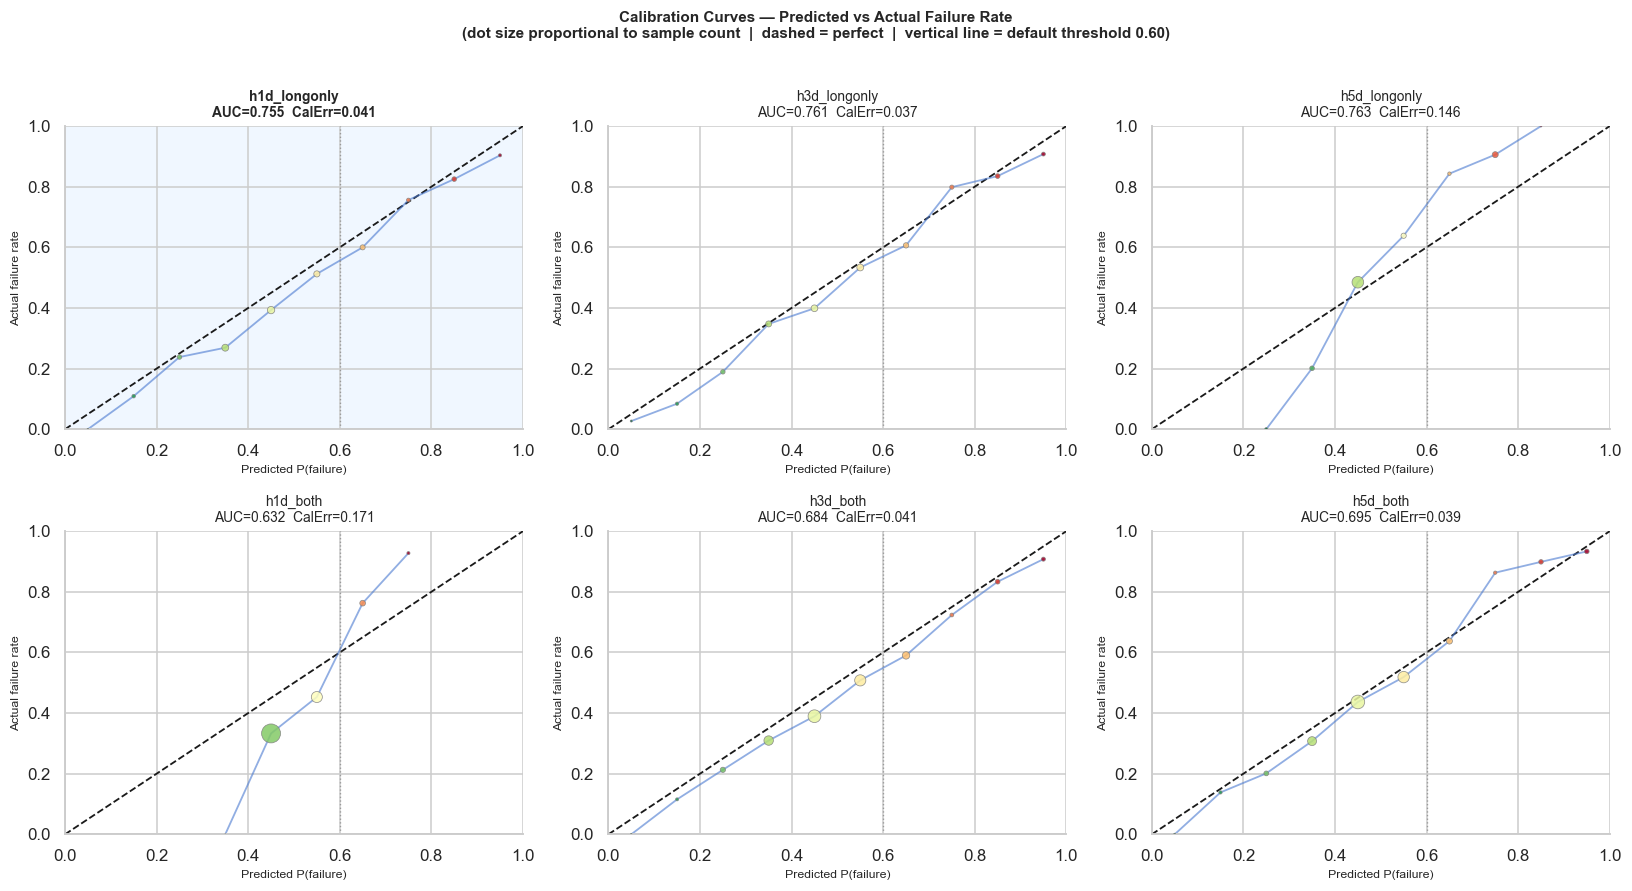


Calibration error (mean absolute deviation from diagonal):
  h1d_longonly          CalErr=0.0406  <- ACTIVE
  h3d_longonly          CalErr=0.0369
  h5d_longonly          CalErr=0.1459
  h1d_both              CalErr=0.1709
  h3d_both              CalErr=0.0410
  h5d_both              CalErr=0.0389


In [10]:
# ── Calibration curves for all variants ───────────────────────────────────────
N_BINS = 10

n_variants = len(eval_results)
ncols = min(3, n_variants)
nrows = (n_variants + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
ax_flat = axes.flatten()

for idx, (vname, r) in enumerate(eval_results.items()):
    ax = ax_flat[idx]
    probas = r['probas']
    y_true = r['y_val']

    bins = np.linspace(0, 1, N_BINS + 1)
    bin_idx = np.clip(np.digitize(probas, bins) - 1, 0, N_BINS - 1)

    # Reset per variant — lists must NOT carry over from previous iterations
    bin_centers, actual_rates, counts = [], [], []
    for b in range(N_BINS):
        mask = bin_idx == b
        if mask.sum() < 5:
            continue
        bin_centers.append(bins[b] + (bins[b + 1] - bins[b]) / 2)
        actual_rates.append(y_true[mask].mean())
        counts.append(int(mask.sum()))

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfect calibration')
    if bin_centers:
        ax.scatter(bin_centers, actual_rates, s=[c / 20 for c in counts],
                   c=bin_centers, cmap='RdYlGn_r', alpha=0.85,
                   edgecolors='gray', linewidth=0.5, zorder=3)
        ax.plot(bin_centers, actual_rates, 'b-', linewidth=1.2, alpha=0.6)

    cal_err = (np.mean(np.abs(np.array(bin_centers) - np.array(actual_rates)))
               if bin_centers else float('nan'))
    ax.set_title(f'{vname}\nAUC={r["auc"]:.3f}  CalErr={cal_err:.3f}',
                 fontweight='bold' if vname == ACTIVE else 'normal', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted P(failure)', fontsize=8)
    ax.set_ylabel('Actual failure rate', fontsize=8)
    ax.axvline(0.60, color='gray', linestyle=':', linewidth=0.9, alpha=0.7)
    if vname == ACTIVE:
        ax.set_facecolor('#f0f7ff')

for idx in range(n_variants, len(ax_flat)):
    ax_flat[idx].set_visible(False)

fig.suptitle('Calibration Curves — Predicted vs Actual Failure Rate\n'
             '(dot size proportional to sample count  |  dashed = perfect  |  '
             'vertical line = default threshold 0.60)',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nCalibration error (mean absolute deviation from diagonal):')
for vname, r in eval_results.items():
    probas = r['probas']
    y_true = r['y_val']
    bins = np.linspace(0, 1, N_BINS + 1)
    bin_idx = np.clip(np.digitize(probas, bins) - 1, 0, N_BINS - 1)
    errs = []
    for b in range(N_BINS):
        mask = bin_idx == b
        if mask.sum() >= 5:
            bc = bins[b] + (bins[b + 1] - bins[b]) / 2
            errs.append(abs(bc - y_true[mask].mean()))
    cal = np.mean(errs) if errs else float('nan')
    active_mark = '  <- ACTIVE' if vname == ACTIVE else ''
    print(f'  {vname:<20s}  CalErr={cal:.4f}{active_mark}')

---
## 5. Signal Volume Over Time

How many alert events fire per month? This shows:
- Whether the model has enough raw material to trade (low-signal months → fewer opportunities)
- Regime shifts: crowding spikes during vol events, crashes, and trend changes
- Stability of the training data distribution over time

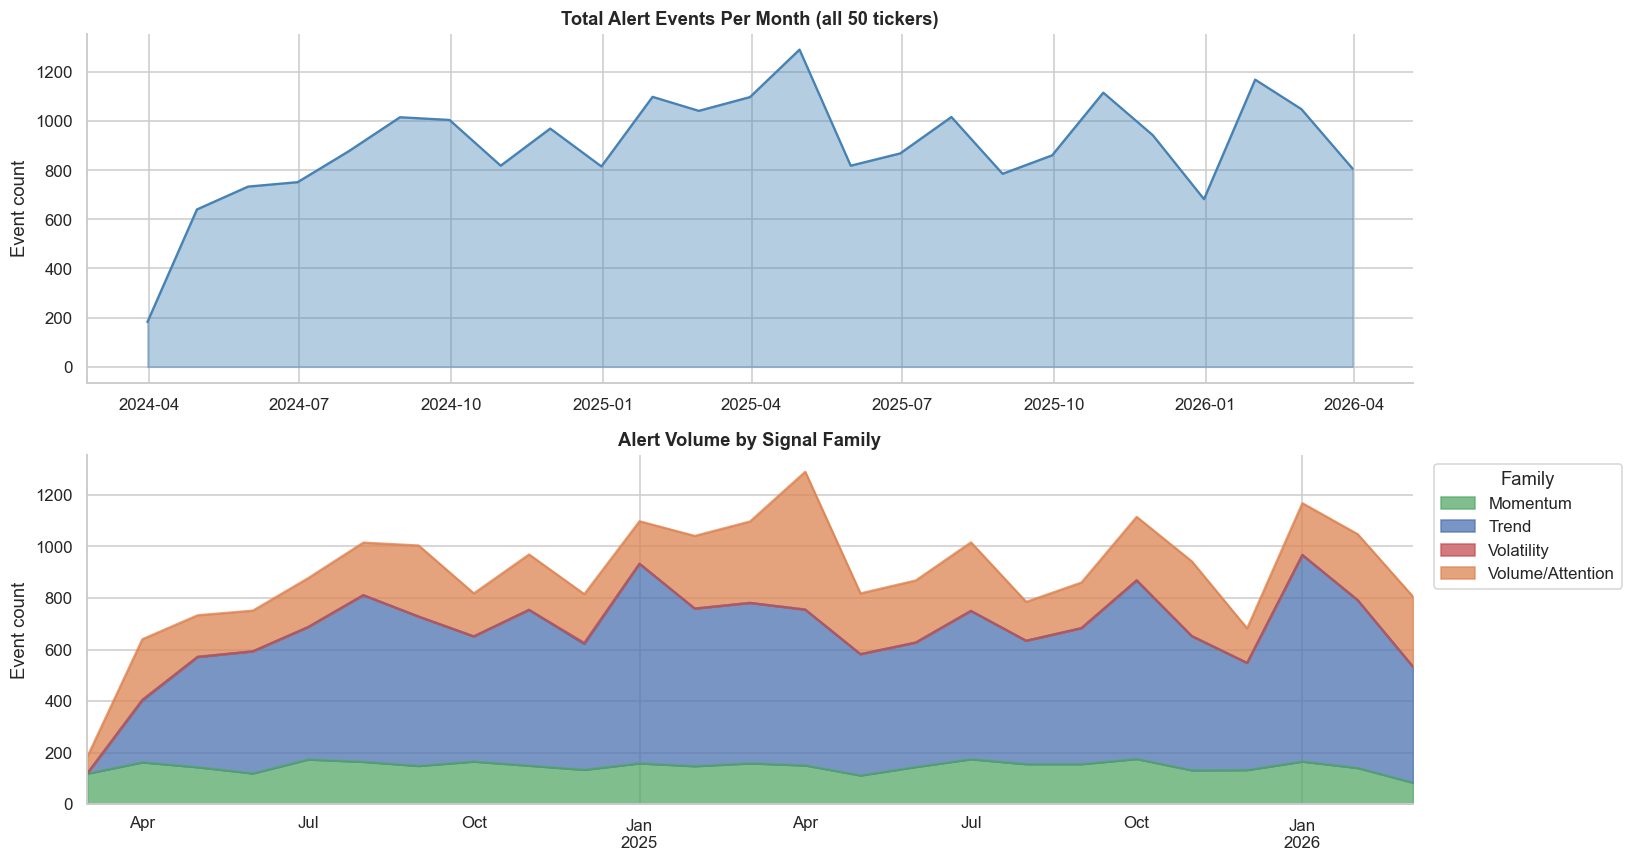

Monthly event stats:
  Mean: 898 events/month
  Median: 877 events/month
  Min: 182  Max: 1290
  Estimated live signals/month (50 stocks, 20 trading days): ~895

  KEY FINDINGS — FAILURE OF CROWDED TECHNICAL SIGNALS

1. SIGNAL BASE RATES
   h=1d  base failure rate: 36.8%  (below 50% — continuation slightly favored)
   h=3d  base failure rate: 43.8%  (below 50% — continuation slightly favored)
   h=5d  base failure rate: 46.0%  (below 50% — continuation slightly favored)

2. MODEL DISCRIMINATION (ROC-AUC on chronological hold-out)
   h1d_longonly          AUC=0.7551  <- ACTIVE
   h3d_longonly          AUC=0.7607
   h5d_longonly          AUC=0.7631
   h1d_both              AUC=0.6319
   h3d_both              AUC=0.6836
   h5d_both              AUC=0.6946

3. BREAK-EVEN ANALYSIS
   SL=1.5%  TP=2.5%  Commission=0.10% round-trip
   Break-even precision: 40%
   Reward/risk: 1.67:1

   Precision at recommended threshold (0.60) vs break-even:
   h1d_longonly          P@0.60=74.1%  n=609  [ABOV

In [11]:
# ── Monthly alert volume ───────────────────────────────────────────────────────
monthly_total = labeled.set_index('date').resample('ME')['alert_name'].count()
monthly_by_family = (
    labeled.copy()
    .assign(family=labeled['alert_name'].map(lambda x:
        'Trend'    if any(k in x for k in ['breakout','ma_cross']) else
        'Momentum' if any(k in x for k in ['rsi','macd','stoch']) else
        'Volatility' if any(k in x for k in ['bollinger','atr','large_candle']) else
        'Volume/Attention'))
    .set_index('date')
    .groupby('family')
    .resample('ME')['alert_name'].count()
    .unstack(level=0)
    .fillna(0)
)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Total volume
axes[0].fill_between(monthly_total.index, monthly_total.values, alpha=0.4, color='steelblue')
axes[0].plot(monthly_total.index, monthly_total.values, color='steelblue', linewidth=1.5)
axes[0].set_title('Total Alert Events Per Month (all 50 tickers)', fontweight='bold')
axes[0].set_ylabel('Event count')
axes[0].set_xlabel('')

# By family
if not monthly_by_family.empty:
    colors_fam = {'Trend': '#4C72B0', 'Momentum': '#55A868',
                  'Volatility': '#C44E52', 'Volume/Attention': '#DD8452'}
    monthly_by_family.plot.area(ax=axes[1], alpha=0.75,
                                color=[colors_fam.get(c, 'gray') for c in monthly_by_family.columns])
    axes[1].set_title('Alert Volume by Signal Family', fontweight='bold')
    axes[1].set_ylabel('Event count')
    axes[1].set_xlabel('')
    axes[1].legend(title='Family', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Summary stats
print(f'Monthly event stats:')
print(f'  Mean: {monthly_total.mean():.0f} events/month')
print(f'  Median: {monthly_total.median():.0f} events/month')
print(f'  Min: {monthly_total.min():.0f}  Max: {monthly_total.max():.0f}')
print(f'  Estimated live signals/month (50 stocks, 20 trading days): ~{monthly_total.median() / labeled["ticker"].nunique() * 50:.0f}')

# ─────────────────────────────────────────────────────────────────────────────
# ── Key Findings Summary ──────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
print()
print('=' * 65)
print('  KEY FINDINGS — FAILURE OF CROWDED TECHNICAL SIGNALS')
print('=' * 65)

print('\n1. SIGNAL BASE RATES')
for h in [1, 3, 5]:
    col = f'label_failure_{h}d'
    if col in labeled.columns:
        rate = labeled[col].mean()
        print(f'   h={h}d  base failure rate: {rate:.1%}  '
              f'({"above" if rate > 0.5 else "below"} 50% — '
              f'{"systematic reversal tendency" if rate > 0.5 else "continuation slightly favored"})')

print('\n2. MODEL DISCRIMINATION (ROC-AUC on chronological hold-out)')
for vname, r in eval_results.items():
    active_mark = '  <- ACTIVE' if vname == ACTIVE else ''
    print(f'   {vname:<20s}  AUC={r["auc"]:.4f}{active_mark}')

print(f'\n3. BREAK-EVEN ANALYSIS')
print(f'   SL=1.5%  TP=2.5%  Commission=0.10% round-trip')
print(f'   Break-even precision: {BREAKEVEN:.0%}')
print(f'   Reward/risk: {0.025 / 0.015:.2f}:1')
print()
print('   Precision at recommended threshold (0.60) vs break-even:')
for vname, r in eval_results.items():
    s = r['thr'].get(0.60, {})
    prec = s.get('prec', float('nan'))
    n    = s.get('n', 0)
    if not np.isnan(prec):
        above = prec >= BREAKEVEN
        flag  = 'ABOVE break-even' if above else 'BELOW break-even'
        active_mark = '  <- ACTIVE' if vname == ACTIVE else ''
        print(f'   {vname:<20s}  P@0.60={prec:.1%}  n={n:,}  [{flag}]{active_mark}')

print('\n4. RECOMMENDED OPERATING POINT')
if ACTIVE in eval_results:
    r = eval_results[ACTIVE]
    best_t, best_p = 0.60, 0.0
    for t in THRESHOLDS:
        s = r['thr'][t]
        if not np.isnan(s['prec']) and s['prec'] >= BREAKEVEN and s['n'] >= 20:
            if s['prec'] > best_p:
                best_p, best_t = s['prec'], t
    if best_p > 0:
        bn = r['thr'][best_t]['n']
        print(f'   Variant: {ACTIVE}')
        print(f'   Threshold: {best_t}  ->  Precision={best_p:.1%}  Signals={bn:,} in hold-out')
        print(f'   Expected value per trade: {best_p * 0.025 - (1 - best_p) * 0.015:.3%} (gross)')
    else:
        print(f'   No threshold above break-even for {ACTIVE} — consider retraining or adjusting SL/TP')